In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rockinbrock/spy-1-minute-data")

print("Path to dataset files:", path)

100%|██████████| 22.1M/22.1M [00:02<00:00, 10.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rockinbrock/spy-1-minute-data/versions/1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv(path + "/spy_1min_2008_2021_cleaned.csv", parse_dates=['date'])
df = df.sort_values('date')
df.head()


,date,open,high,low,close,volume,barCount,average
0,2008-01-22 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
1,2008-01-22 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2,2008-01-22 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
3,2008-01-22 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
4,2008-01-22 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730


In [ ]:
def plot_graph(label=0):
  features = ['open', 'high', 'low', 'close', 'volume', 'barCount', 'average']
  df.plot(x='date', y=features[label])
  plt.title(f'Plot of {features[label]} over Time')
  plt.xlabel('Date')
  plt.ylabel(features[label])
  plt.show()

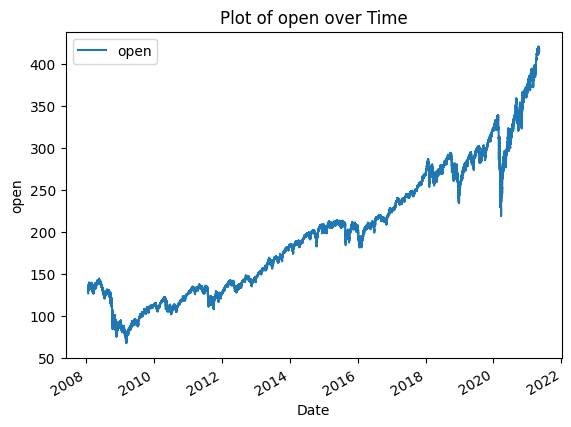

In [ ]:
# Open
plot_graph()

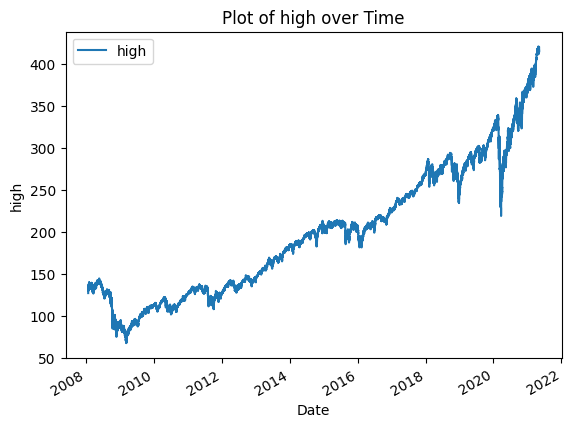

In [ ]:
# High
plot_graph(1)

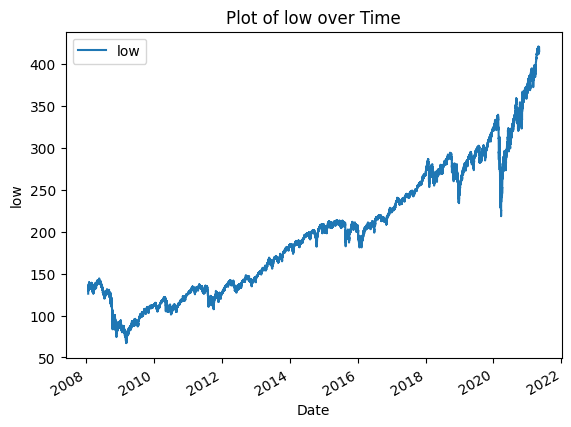

In [ ]:
plot_graph(2)

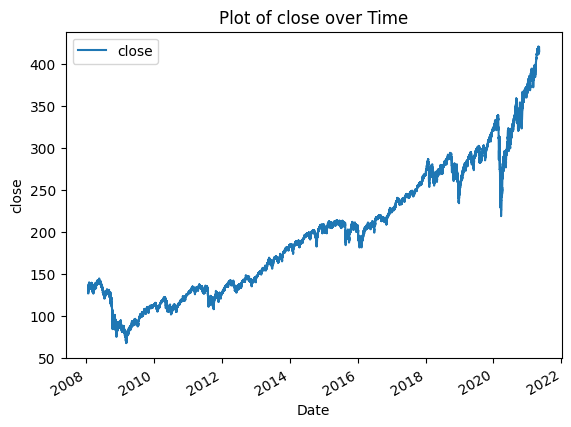

In [ ]:
plot_graph(3)

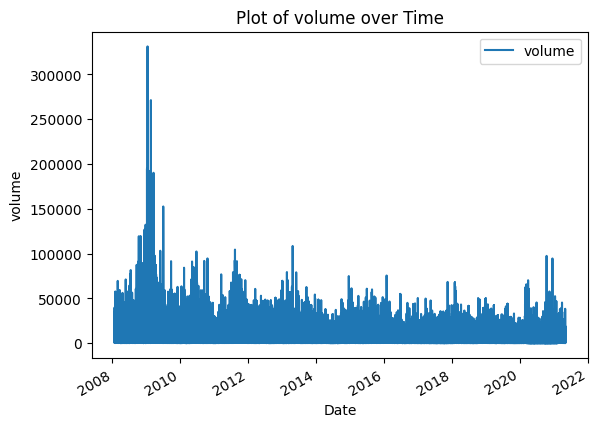

In [ ]:
plot_graph(4)

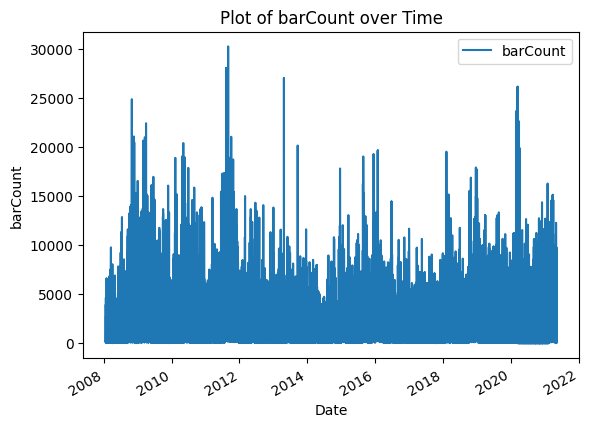

In [ ]:
plot_graph(5)

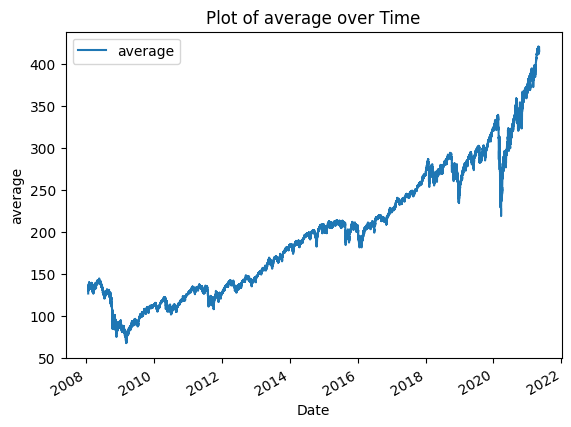

In [ ]:
plot_graph(6)

In [ ]:
import math
def long_term(t):
  return [math.exp(t), t]

def short_term(t, n):
  # Make sure that you readjust period so that 1 year is pi/2 in this case
  sins_and_cos = []
  for i in range(n):
    sins_and_cos.append(math.sin(t * i * math.pi / 2))
    sins_and_cos.append(math.cos(t * i * math.pi / 2))
  return sins_and_cos


In [ ]:
# Normalize the dates in the dataframe such that 1 year = 1
reference_date = df['date'][0]
time_difference = df['date'] - reference_date
minutes_data = time_difference.dt.total_seconds() / 60

In [ ]:
df

,date,open,high,low,close,volume,barCount,average
0,2008-01-22 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
1,2008-01-22 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2,2008-01-22 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
3,2008-01-22 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
4,2008-01-22 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730
...,...,...,...,...,...,...,...,...
2070829,2021-05-06 13:55:00,418.56,418.77,418.48,418.49,9073,4584,418.660
2070830,2021-05-06 13:56:00,418.50,418.73,418.47,418.64,6680,3095,418.622
2070831,2021-05-06 13:57:00,418.64,418.79,418.63,418.79,6912,2868,418.744
2070832,2021-05-06 13:58:00,418.79,418.83,418.71,418.76,7891,3862,418.784


In [ ]:
MIN_IN_YEAR = 60 * 24 * 365
minutes_data = minutes_data / MIN_IN_YEAR

In [ ]:
long_term_data = [long_term(x) for x in minutes_data]
long_term_data = np.array(long_term_data)
long_term_data

array([[1.00000000e+00, 0.00000000e+00],
       [1.00000190e+00, 1.90258752e-06],
       [1.00000381e+00, 3.80517504e-06],
       ...,
       [5.95184495e+05, 1.32966267e+01],
       [5.95185628e+05, 1.32966286e+01],
       [5.95186760e+05, 1.32966305e+01]])

In [ ]:
short_term_data = [short_term(x, 64) for x in minutes_data]
short_term_data = np.array(short_term_data)
short_term_data

array([[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  2.98857749e-06, ...,
         9.99999983e-01,  1.88280381e-04,  9.99999982e-01],
       [ 0.00000000e+00,  1.00000000e+00,  5.97715497e-06, ...,
         9.99999931e-01,  3.76560754e-04,  9.99999929e-01],
       ...,
       [ 0.00000000e+00,  1.00000000e+00,  8.93399586e-01, ...,
         8.17375676e-01,  4.71420458e-01, -8.81908585e-01],
       [ 0.00000000e+00,  1.00000000e+00,  8.93398243e-01, ...,
         8.17268915e-01,  4.71254403e-01, -8.81997328e-01],
       [ 0.00000000e+00,  1.00000000e+00,  8.93396901e-01, ...,
         8.17162125e-01,  4.71088332e-01, -8.82086041e-01]])

In [ ]:
long_term_data = pd.DataFrame(long_term_data)
long_term_data.columns = ['exp', 't']
long_term_data

,exp,t
0,1.000000,0.000000
1,1.000002,0.000002
2,1.000004,0.000004
3,1.000006,0.000006
4,1.000008,0.000008
...,...,...
2070829,595182.230363,13.296623
2070830,595183.362750,13.296625
2070831,595184.495139,13.296627
2070832,595185.627531,13.296629


In [ ]:
short_term_data = pd.DataFrame(short_term_data)
short_term_data

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,0.0,1.0,0.000003,1.000000,0.000006,1.000000,0.000009,1.000000,0.000012,1.000000,...,0.000176,1.000000,0.000179,1.000000,0.000182,1.000000,0.000185,1.000000,0.000188,1.000000
2,0.0,1.0,0.000006,1.000000,0.000012,1.000000,0.000018,1.000000,0.000024,1.000000,...,0.000353,1.000000,0.000359,1.000000,0.000365,1.000000,0.000371,1.000000,0.000377,1.000000
3,0.0,1.0,0.000009,1.000000,0.000018,1.000000,0.000027,1.000000,0.000036,1.000000,...,0.000529,1.000000,0.000538,1.000000,0.000547,1.000000,0.000556,1.000000,0.000565,1.000000
4,0.0,1.0,0.000012,1.000000,0.000024,1.000000,0.000036,1.000000,0.000048,1.000000,...,0.000705,1.000000,0.000717,1.000000,0.000729,1.000000,0.000741,1.000000,0.000753,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070829,0.0,1.0,0.893402,-0.449258,-0.802736,-0.596335,-0.172132,0.985074,0.957399,-0.288769,...,0.707941,0.706272,0.312937,-0.949774,-0.989119,0.147115,0.575802,0.817589,0.471753,-0.881731
2070830,0.0,1.0,0.893401,-0.449260,-0.802739,-0.596330,-0.172123,0.985075,0.957395,-0.288780,...,0.708066,0.706147,0.312766,-0.949830,-0.989093,0.147295,0.575954,0.817482,0.471586,-0.881820
2070831,0.0,1.0,0.893400,-0.449263,-0.802743,-0.596326,-0.172115,0.985077,0.957392,-0.288791,...,0.708190,0.706022,0.312596,-0.949886,-0.989066,0.147475,0.576105,0.817376,0.471420,-0.881909
2070832,0.0,1.0,0.893398,-0.449266,-0.802746,-0.596321,-0.172106,0.985078,0.957389,-0.288803,...,0.708315,0.705897,0.312426,-0.949942,-0.989039,0.147656,0.576256,0.817269,0.471254,-0.881997


In [ ]:
partial_model_data = pd.concat([long_term_data, short_term_data], axis=1)
partial_model_data

,exp,t,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,1.000000,0.000000,0.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,1.000002,0.000002,0.0,1.0,0.000003,1.000000,0.000006,1.000000,0.000009,1.000000,...,0.000176,1.000000,0.000179,1.000000,0.000182,1.000000,0.000185,1.000000,0.000188,1.000000
2,1.000004,0.000004,0.0,1.0,0.000006,1.000000,0.000012,1.000000,0.000018,1.000000,...,0.000353,1.000000,0.000359,1.000000,0.000365,1.000000,0.000371,1.000000,0.000377,1.000000
3,1.000006,0.000006,0.0,1.0,0.000009,1.000000,0.000018,1.000000,0.000027,1.000000,...,0.000529,1.000000,0.000538,1.000000,0.000547,1.000000,0.000556,1.000000,0.000565,1.000000
4,1.000008,0.000008,0.0,1.0,0.000012,1.000000,0.000024,1.000000,0.000036,1.000000,...,0.000705,1.000000,0.000717,1.000000,0.000729,1.000000,0.000741,1.000000,0.000753,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070829,595182.230363,13.296623,0.0,1.0,0.893402,-0.449258,-0.802736,-0.596335,-0.172132,0.985074,...,0.707941,0.706272,0.312937,-0.949774,-0.989119,0.147115,0.575802,0.817589,0.471753,-0.881731
2070830,595183.362750,13.296625,0.0,1.0,0.893401,-0.449260,-0.802739,-0.596330,-0.172123,0.985075,...,0.708066,0.706147,0.312766,-0.949830,-0.989093,0.147295,0.575954,0.817482,0.471586,-0.881820
2070831,595184.495139,13.296627,0.0,1.0,0.893400,-0.449263,-0.802743,-0.596326,-0.172115,0.985077,...,0.708190,0.706022,0.312596,-0.949886,-0.989066,0.147475,0.576105,0.817376,0.471420,-0.881909
2070832,595185.627531,13.296629,0.0,1.0,0.893398,-0.449266,-0.802746,-0.596321,-0.172106,0.985078,...,0.708315,0.705897,0.312426,-0.949942,-0.989039,0.147656,0.576256,0.817269,0.471254,-0.881997


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
partial_model_data.columns = partial_model_data.columns.astype(str)
partial_model_data

,exp,t,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,1.000000,0.000000,0.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,1.000002,0.000002,0.0,1.0,0.000003,1.000000,0.000006,1.000000,0.000009,1.000000,...,0.000176,1.000000,0.000179,1.000000,0.000182,1.000000,0.000185,1.000000,0.000188,1.000000
2,1.000004,0.000004,0.0,1.0,0.000006,1.000000,0.000012,1.000000,0.000018,1.000000,...,0.000353,1.000000,0.000359,1.000000,0.000365,1.000000,0.000371,1.000000,0.000377,1.000000
3,1.000006,0.000006,0.0,1.0,0.000009,1.000000,0.000018,1.000000,0.000027,1.000000,...,0.000529,1.000000,0.000538,1.000000,0.000547,1.000000,0.000556,1.000000,0.000565,1.000000
4,1.000008,0.000008,0.0,1.0,0.000012,1.000000,0.000024,1.000000,0.000036,1.000000,...,0.000705,1.000000,0.000717,1.000000,0.000729,1.000000,0.000741,1.000000,0.000753,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070829,595182.230363,13.296623,0.0,1.0,0.893402,-0.449258,-0.802736,-0.596335,-0.172132,0.985074,...,0.707941,0.706272,0.312937,-0.949774,-0.989119,0.147115,0.575802,0.817589,0.471753,-0.881731
2070830,595183.362750,13.296625,0.0,1.0,0.893401,-0.449260,-0.802739,-0.596330,-0.172123,0.985075,...,0.708066,0.706147,0.312766,-0.949830,-0.989093,0.147295,0.575954,0.817482,0.471586,-0.881820
2070831,595184.495139,13.296627,0.0,1.0,0.893400,-0.449263,-0.802743,-0.596326,-0.172115,0.985077,...,0.708190,0.706022,0.312596,-0.949886,-0.989066,0.147475,0.576105,0.817376,0.471420,-0.881909
2070832,595185.627531,13.296629,0.0,1.0,0.893398,-0.449266,-0.802746,-0.596321,-0.172106,0.985078,...,0.708315,0.705897,0.312426,-0.949942,-0.989039,0.147656,0.576256,0.817269,0.471254,-0.881997


In [ ]:
# Long-term + Short-Term Regression on Open
X = partial_model_data
y = df['open']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_open = LinearRegression()
model_open.fit(X_train, y_train)

y_pred = model_open.predict(X_test)
r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared}")

R-squared: 0.9629946295834333


In [ ]:
models = {}

In [ ]:
features = ['open', 'high', 'low', 'close', 'volume', 'barCount', 'average']
for i in features:
  X = partial_model_data
  y = df[i]
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  model = LinearRegression()
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  r_squared = r2_score(y_test, y_pred)
  print(f"R-squared of {i}: {r_squared}")
  models[i] = model

R-squared of open: 0.9629946295834333
R-squared of high: 0.9630288183591993
R-squared of low: 0.9629604075550279
R-squared of close: 0.9629929946249869
R-squared of volume: 0.20897027938784984
R-squared of barCount: 0.15448741283673006
R-squared of average: 0.9629949144060919


In [ ]:
SEQ_LEN = 7200   # past window length
HORIZON = 60     # predict next 60 minutes
features = ['open','high','low','close','volume','barCount','average']

X = df[features].values  # shape (N, 7)
Y = df['close'].values   # target variable


In [ ]:
time_values = partial_model_data[['t']].values
time_values

array([[0.00000000e+00],
       [1.90258752e-06],
       [3.80517504e-06],
       ...,
       [1.32966267e+01],
       [1.32966286e+01],
       [1.32966305e+01]])

In [ ]:
time_values.shape

(2070834, 1)

In [ ]:
Y.shape

(2070834,)

In [ ]:
time_values = time_values.reshape(2070834, 1)

In [ ]:
time_values.shape

(2070834, 1)

In [ ]:
L_S = models['close'].predict(partial_model_data)

In [ ]:
L_S.shape

(2070834,)

In [ ]:
# Residuals

R = Y - L_S

In [ ]:
X_seq, y_seq = [], []
for i in range(0, len(df) - SEQ_LEN - HORIZON, 30):
    X_seq.append(X[i:i+SEQ_LEN])                       # shape (7200, 7)
    y_seq.append(R[i+SEQ_LEN:i+SEQ_LEN+HORIZON])       # next 60 residuals
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

In [ ]:
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_residual_model(input_shape, horizon=60, use_gru=False):
    ModelLayer = layers.GRU if use_gru else layers.LSTM
    model = models.Sequential([
        ModelLayer(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        ModelLayer(64),
        layers.Dense(128, activation='relu'),
        layers.Dense(horizon)   # predict next 60 residuals
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

residual_model = build_residual_model((SEQ_LEN, 7), horizon=HORIZON, use_gru=False)
residual_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 7200, 64)       │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7200, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 60)             │         7,740 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,516 (263.73 KB)

 Trainable params: 67,516 (263.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = residual_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
6879/6879 ━━━━━━━━━━━━━━━━━━━━ 2579s 375ms/step - loss: 217.9173 - val_loss: 375.6237
Epoch 2/20
6879/6879 ━━━━━━━━━━━━━━━━━━━━ 2580s 375ms/step - loss: 131.4767 - val_loss: 783.9554
Epoch 3/20
 865/6879 ━━━━━━━━━━━━━━━━━━━━ 33:32 335ms/step - loss: 50.2033

In [ ]:
residual_model.save('residual_model.keras')
residual_model.save('residual_model.h5')